# 02 — MORE vs LESS access

Diverging bar charts showing which group categories gain (`MORE`) or lose
(`LESS`) access to resources, with the top 2 chi²-specific resource
categories per side. Uses the gold-filtered final dataset only — no NLP
harmonisation; `group_meta` and `resource_meta` are the anchored
canonical categories already assigned upstream.

1. **All periods combined.**
2. **Per period** — one chart for each of the 4 historical windows.

*Follows `notebook_rule.md`: load at top, preprocess separately, one
figure per cell under its own `### Figure N` header, styling defined in
one config cell, no figures saved to disk.*

## 1. Setup — imports, style, constants

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

DATA = Path('../data/clean/final/rules_final_dataset_130works_april_2026.tsv')

# Group buckets to exclude — too small / noisy for the MORE–LESS comparison.
EXCLUDE_GROUPS = {
    'Soldiers', 'Artisans', 'Philosophers',
    'The multitude', 'Heirs', 'Priests',
}

# Minimum total rules a group needs in a given panel to be drawn.
MIN_TOTAL_ALL = 10
MIN_TOTAL_PERIOD = 5

In [2]:
# Science-journal minimal style — defined once, used throughout.
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0,
    'xtick.major.size': 3,
    'ytick.major.size': 0,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'legend.frameon': False,
})

LESS_COLOR = '#c0392b'
MORE_COLOR = '#2c6e91'

## 2. Load data

In [3]:
df_raw = pd.read_csv(DATA, sep='\t')
print(f'Loaded {len(df_raw):,} rules from {DATA.name}')
df_raw[['rule', 'directionality', 'group_meta', 'resource_meta', 'period']].head()

Loaded 1,011 rules from rules_final_dataset_130works_april_2026.tsv


,rule,directionality,group_meta,resource_meta,period
0,Greek exclusion from large-scale statecraft,LESS,Greeks,Political power,Hellenistic & Early Roman (165 BCE – 105 CE)
1,City-state local self-government,MORE,Greeks,Political power,Hellenistic & Early Roman (165 BCE – 105 CE)
2,Noble access to magistracies,MORE,Nobles,Eligibility for public office,Hellenistic & Early Roman (165 BCE – 105 CE)
3,Citizen assembly voting,MORE,Citizens,Right to vote in the Ekklesia,Hellenistic & Early Roman (165 BCE – 105 CE)
4,Proconsular annulment of local power,LESS,Citizens,Political power,Hellenistic & Early Roman (165 BCE – 105 CE)


## 3. Preprocessing

Filter to rated rules (MORE / LESS) with a known `group_meta` and
`resource_meta`, then drop small / noisy group buckets. Row counts are
logged at every step.

In [4]:
n0 = len(df_raw)

df = df_raw[df_raw['directionality'].isin(['MORE', 'LESS'])
            & df_raw['group_meta'].notna()
            & df_raw['resource_meta'].notna()].copy()
n1 = len(df)

df = df[~df['group_meta'].isin(EXCLUDE_GROUPS)].copy()
n2 = len(df)

# Integrity checks.
assert df['directionality'].isin(['MORE', 'LESS']).all()
assert df['group_meta'].notna().all()
assert df['resource_meta'].notna().all()

print(f'Raw:                                    {n0:,}')
print(f'After MORE/LESS + group/resource filter: {n1:,}  (dropped {n0-n1})')
print(f'After excluding small group buckets:     {n2:,}  (dropped {n1-n2})')
print(f'\n{df["group_meta"].nunique()} group categories | '
      f'{df["resource_meta"].nunique()} resource categories | '
      f'{df["period"].nunique(dropna=False)} period buckets')
print(f'Excluded groups: {sorted(EXCLUDE_GROUPS)}')
df.head()

Raw:                                    1,011
After MORE/LESS + group/resource filter: 1,011  (dropped 0)
After excluding small group buckets:     920  (dropped 91)

31 group categories | 44 resource categories | 5 period buckets
Excluded groups: ['Artisans', 'Heirs', 'Philosophers', 'Priests', 'Soldiers', 'The multitude']


,rule_uid,file_id,perseus_author,perseus_title,wikidata_work_id,wikidata_work_label,author_wikidata_id,author_impact_date,year,period,...,persistence_reasoning,group_immutability,immutability_reasoning,rule_contemporarity,contemporarity_reasoning,opinion_vs_fact,opinion_vs_fact_reasoning,tautology,tautology_reasoning,resource_type
0,tlg0007.tlg118.perseus-eng3::0,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Exclusion from high office is a durable career...,5,Greek ethnicity is a birth-fixed biological/cu...,0,Plutarch describes the current Roman administr...,5,Verbatim states the limitation as a plain hist...,0,Ethnicity does not inherently define level of ...,Political Power
1,tlg0007.tlg118.perseus-eng3::1,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,A city's status and its citizens' collective r...,4,Citizenship in a Greek city-state is a rigid l...,0,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...,Political Power
2,tlg0007.tlg118.perseus-eng3::2,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Elite status and eligibility for office are ty...,5,'Noble birth' is a strictly immutable lineage-...,0,Plutarch addresses a living recipient about hi...,4,"Frames eligibility as a matter of birthright, ...",0,Nobility does not always formally mandate poli...,Political Power
3,tlg0007.tlg118.perseus-eng3::3,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Citizen voting rights are generally lifelong f...,4,Status as 'Athenian citizens' and 'free men' i...,0,Refers to the current population of Athens rul...,4,"While hortatory, it identifies the group as 'f...",0,Being 'free' or 'Greek' does not automatically...,Political Power
4,tlg0007.tlg118.perseus-eng3::5,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,An annulment has a permanent or long-term effe...,4,"Refers to citizens under Roman dominion, a leg...",0,Describes the current legal hierarchy in the R...,4,Asserted as a factual reality of imperial powe...,0,Local citizenship does not conceptually define...,Political Power


## 4. Helpers — chi² specificity & diverging-bar plot

*No figure produced in this cell — only functions.*

In [5]:
def specific_resources(data, group, direction, top_n=2):
    """Top-N resource_meta most distinctive of (group, direction), by chi²."""
    sub = data[(data['group_meta'] == group)
               & (data['directionality'] == direction)]
    rest = data[~((data['group_meta'] == group)
                  & (data['directionality'] == direction))]
    if len(sub) < 3:
        return sub['resource_meta'].value_counts().head(top_n).index.tolist()
    sub_counts = sub['resource_meta'].value_counts()
    rest_counts = rest['resource_meta'].value_counts()
    scored = {}
    for res, a in sub_counts.items():
        if a < 2:
            continue
        b = len(sub) - a
        c = rest_counts.get(res, 0)
        d = len(rest) - c
        try:
            chi2, _p, _dof, exp = chi2_contingency(
                np.array([[a, b], [c, d]]), correction=True)
            if a > exp[0][0]:
                scored[res] = chi2
        except Exception:
            pass
    if scored:
        return sorted(scored, key=scored.get, reverse=True)[:top_n]
    return sub_counts.head(top_n).index.tolist()


def diverging_bar(data, title, min_total=MIN_TOTAL_ALL):
    """Diverging MORE/LESS bars by group_meta, with chi²-specific resources.
    Rows ordered top→bottom by descending share of negative rules."""
    g = (data.groupby(['group_meta', 'directionality']).size()
              .unstack(fill_value=0))
    for d in ['LESS', 'MORE']:
        if d not in g.columns:
            g[d] = 0
    g['total'] = g['LESS'] + g['MORE']
    g = g[g['total'] >= min_total]
    if g.empty:
        print(f'No groups with total >= {min_total} in {title}')
        return
    g['less_ratio'] = g['LESS'] / g['total']
    g = g.sort_values('less_ratio', ascending=False)

    spec_less = {w: specific_resources(data, w, 'LESS') for w in g.index}
    spec_more = {w: specific_resources(data, w, 'MORE') for w in g.index}

    n = len(g)
    fig, ax = plt.subplots(figsize=(13, max(4, 1.0 + n * 0.55)))
    y = np.arange(n)
    ax.barh(y, -g['LESS'], color=LESS_COLOR, edgecolor='white',
            linewidth=0.8, height=0.62)
    ax.barh(y,  g['MORE'], color=MORE_COLOR, edgecolor='white',
            linewidth=0.8, height=0.62)
    ax.invert_yaxis()

    ordered_groups = g.index.tolist()
    ylabels = [f"{w}  ({g.loc[w, 'less_ratio']*100:.0f}%)"
               for w in ordered_groups]
    ax.set_yticks(y)
    for tick, w in zip(ax.set_yticklabels(ylabels, fontsize=9), ordered_groups):
        tick.set_color(LESS_COLOR if g.loc[w, 'less_ratio'] > 0.5 else MORE_COLOR)
    ax.set_ylabel('percent of negative resources', fontsize=9,
                  color='#555', labelpad=8)

    ax.axvline(0, color='#1d1d1f', linewidth=0.8)
    ax.grid(axis='x', alpha=0.12, linewidth=0.4)
    ax.set_axisbelow(True)
    ax.set_title(title, loc='left', fontweight='bold', pad=8)

    mv = max(g['LESS'].max(), g['MORE'].max(), 1)
    ax.set_xlim(-mv - max(40, mv*0.55), mv + max(40, mv*0.55))

    y_arrow = n - 0.1 + 0.8
    arrow_len = mv * 0.45
    ax.annotate('', xy=(-arrow_len, y_arrow), xytext=(-mv*0.02, y_arrow),
                arrowprops=dict(arrowstyle='-|>', lw=1.4, color=LESS_COLOR,
                                shrinkA=0, shrinkB=0, mutation_scale=14),
                annotation_clip=False)
    ax.annotate('', xy=(arrow_len, y_arrow), xytext=(mv*0.02, y_arrow),
                arrowprops=dict(arrowstyle='-|>', lw=1.4, color=MORE_COLOR,
                                shrinkA=0, shrinkB=0, mutation_scale=14),
                annotation_clip=False)
    ax.text(-arrow_len, y_arrow + 0.35, 'negative',
            ha='center', va='top', fontsize=9, color=LESS_COLOR,
            fontweight='bold', clip_on=False)
    ax.text(arrow_len, y_arrow + 0.35, 'positive',
            ha='center', va='top', fontsize=9, color=MORE_COLOR,
            fontweight='bold', clip_on=False)
    ax.set_xlabel('')
    ax.set_ylim(y_arrow + 1.2, -0.5)

    for i, w in enumerate(ordered_groups):
        l = int(g.loc[w, 'LESS']); m = int(g.loc[w, 'MORE'])
        if l > 0:
            ax.text(-l/2, i, str(l), ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')
            for j, res in enumerate(spec_less.get(w, [])):
                ax.text(-l - mv*0.03, i - 0.14 + j * 0.26, res,
                        ha='right', va='center', fontsize=8,
                        color=LESS_COLOR, fontstyle='italic')
        if m > 0:
            ax.text(m/2, i, str(m), ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')
            for j, res in enumerate(spec_more.get(w, [])):
                ax.text(m + mv*0.03, i - 0.14 + j * 0.26, res,
                        ha='left', va='center', fontsize=8,
                        color=MORE_COLOR, fontstyle='italic')
    fig.tight_layout()
    return fig, ax

## 5. Counts per group (all periods)

Before drawing the figures, we print the underlying table of MORE / LESS
counts per group so reviewers can trace every bar to its raw numbers.

In [6]:
all_counts = (df.groupby(['group_meta', 'directionality']).size()
                .unstack(fill_value=0))
for d in ['LESS', 'MORE']:
    if d not in all_counts.columns:
        all_counts[d] = 0
all_counts = all_counts[['MORE', 'LESS']]
all_counts['total'] = all_counts.sum(axis=1)
all_counts['less_ratio_%'] = (100 * all_counts['LESS']
                              / all_counts['total']).round(1)
all_counts = all_counts.sort_values('less_ratio_%', ascending=False)
all_counts

directionality,MORE,LESS,total,less_ratio_%
group_meta,,,,
Freedmen,0,1,1,100.0
Syrians,0,4,4,100.0
Romans,0,1,1,100.0
Christians,1,2,3,66.7
Foreigners,28,51,79,64.6
Slaves,27,48,75,64.0
Greeks,3,5,8,62.5
The wealthy,43,66,109,60.6
Minors,20,27,47,57.4


## 6. Figures

### Figure 1: MORE vs LESS — all periods combined

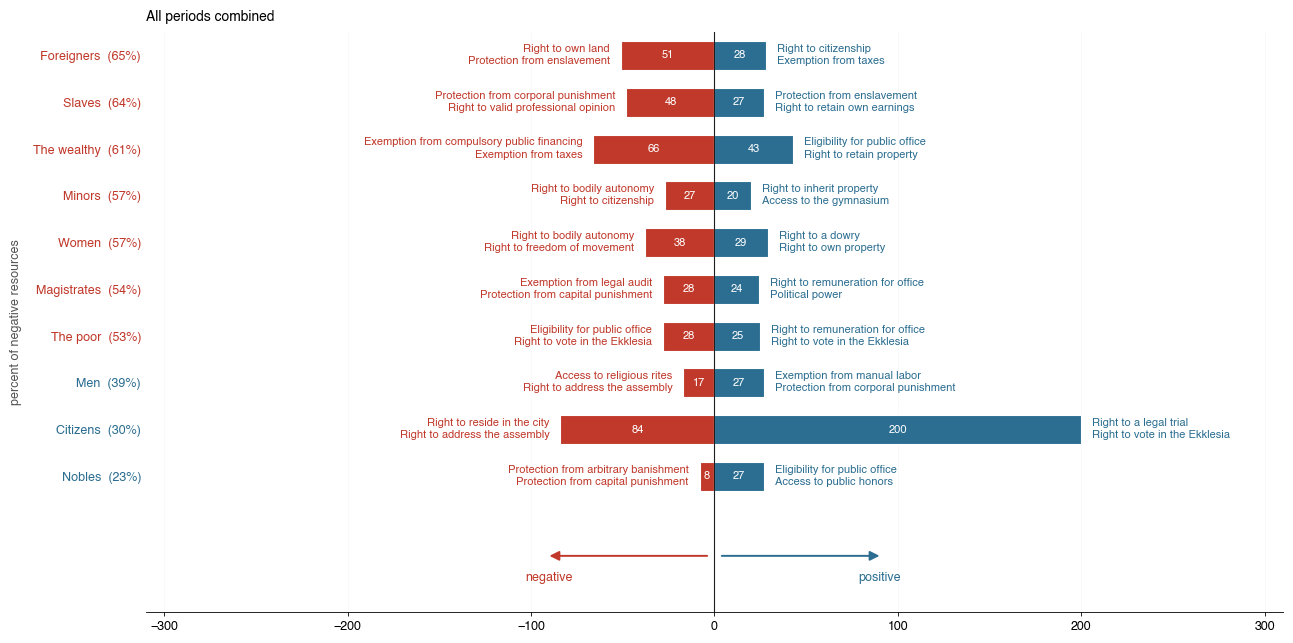

In [7]:
diverging_bar(df, title='All periods combined',
              min_total=MIN_TOTAL_ALL);

### Figure 2: MORE vs LESS — Classical (500–360 BCE)

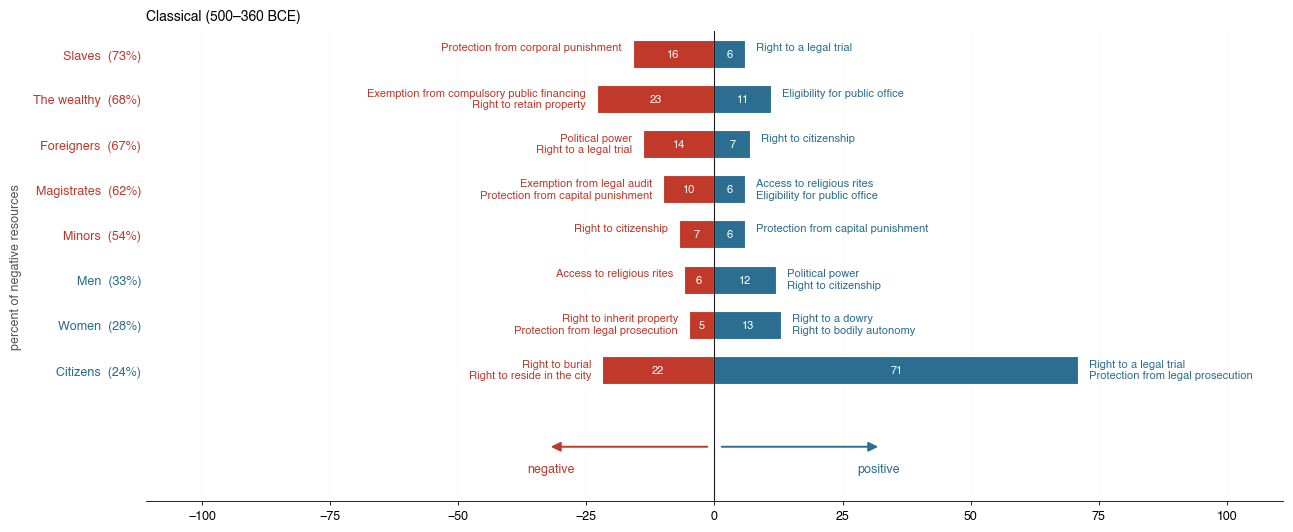

In [8]:
diverging_bar(df[df['period'] == 'Classical (500–360 BCE)'],
              title='Classical (500–360 BCE)',
              min_total=MIN_TOTAL_PERIOD);

### Figure 3: MORE vs LESS — Late Classical (354–165 BCE)

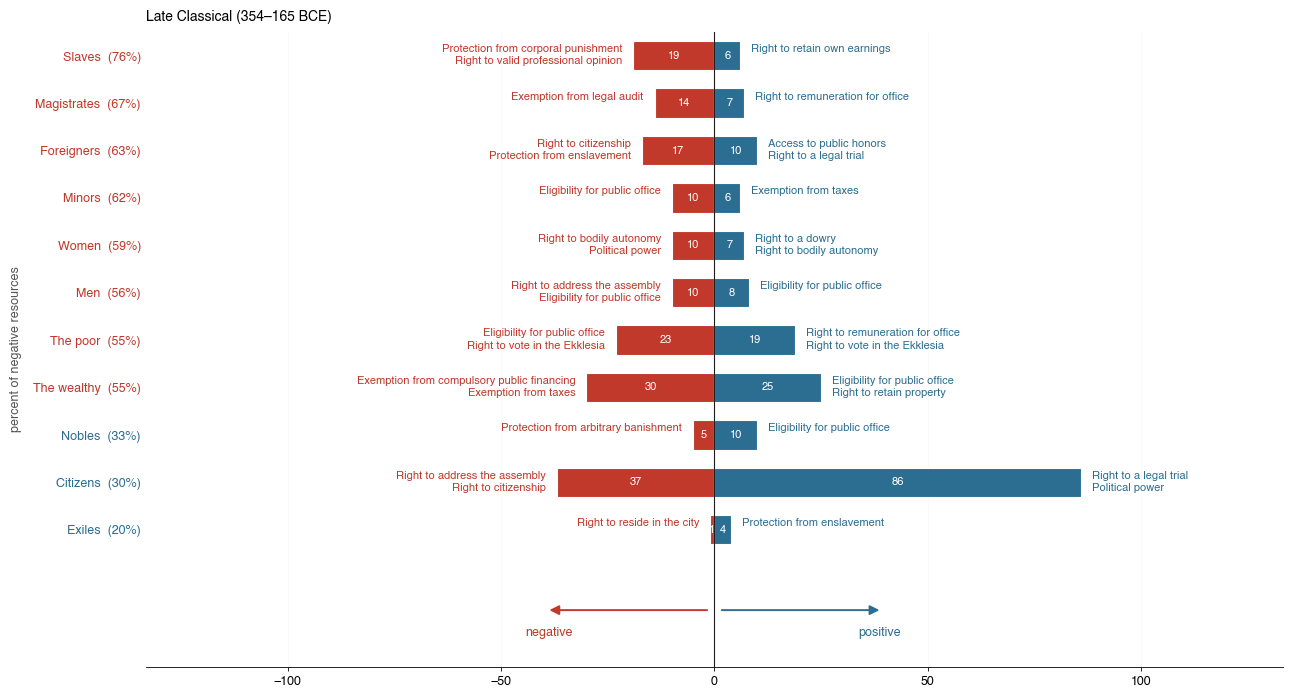

In [9]:
diverging_bar(df[df['period'] == 'Late Classical (354–165 BCE)'],
              title='Late Classical (354–165 BCE)',
              min_total=MIN_TOTAL_PERIOD);

### Figure 4: MORE vs LESS — Hellenistic & Early Roman (165 BCE – 105 CE)

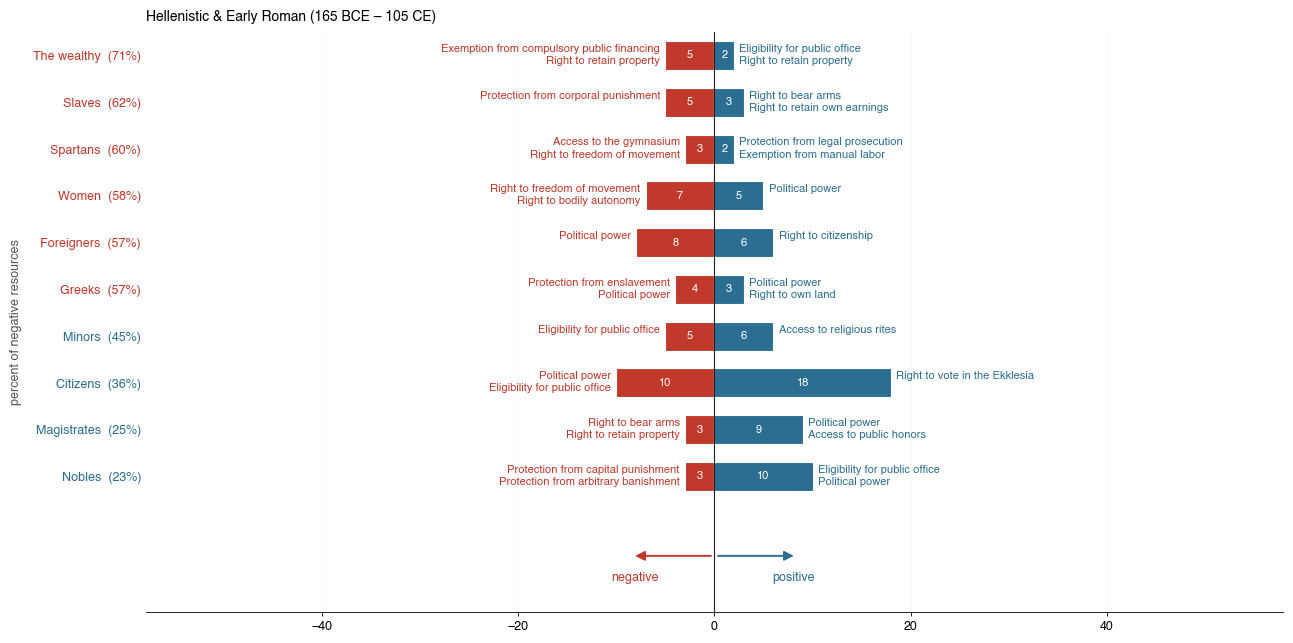

In [10]:
diverging_bar(df[df['period'] == 'Hellenistic & Early Roman (165 BCE – 105 CE)'],
              title='Hellenistic & Early Roman (165 BCE – 105 CE)',
              min_total=MIN_TOTAL_PERIOD);

### Figure 5: MORE vs LESS — High Roman Empire (135–205 CE)

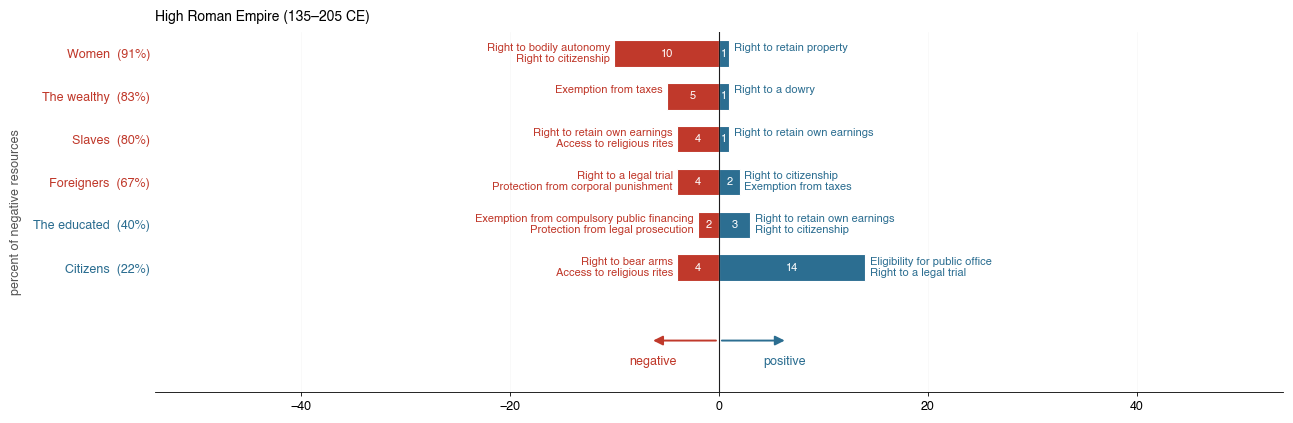

In [11]:
diverging_bar(df[df['period'] == 'High Roman Empire (135–205 CE)'],
              title='High Roman Empire (135–205 CE)',
              min_total=MIN_TOTAL_PERIOD);